# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [13]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [14]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 8)


In [16]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [7]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [8]:
# inspección de usage con .info
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
 6   is_text   40000 non-null  int64  
 7   is_call   40000 non-null  int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 2.4+ MB




## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [9]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [10]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
is_text         0
is_call         0
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
is_text     0.00000
is_call     0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar

**datasets user**
- se encuentran 469 datos nulos en city que equivale al 11.72% de usuarios, es un porcentaje moderado, en columna categorica lo que recomendaria rellenar por unknown par no perder esos registros en el analisis.

-en el caso de churn date, tenemos 3534 nulos que coresponden al 88.35% del total de los usuarios lo que generaria una alerta, pero al tratarse de chrun usuarios de baja significa que estan activos y puede reemplazarse por NaN ya que no es un error puesto que aun utilizan el servicio 

  **datasets usage**
  - los valores nulos se presentab eb date, duracion con el 55% y length con el 44%, sin embargo pertenecen a diferenrtes tipos de eventos, mensajes y llamada, se recomienda hacer un df.groupby('type').count() para confirmar si los nulos de mensajes pertenecen a los nulos de llamadas 



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [11]:
# explorar columnas numéricas de users
print(users["user_id"].describe())
print()
print(users["age"].describe())


count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves
- esta columna no presenta outliers ya que la media y la mediana son exacatemnte iguales, presenta una distribucion simetrica
  
- La columna `age` ...
- Presenta desviacion standar alta, disperso por los valores extremos del min -999, se recomienda reemplazar los valores nulos por la mediana que es 47 ya que se evidencia concentracion entre 45 y 50 años 

In [12]:
# explorar columnas numéricas de usage
print(usage[["id", "user_id", "duration", "length"]].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves
 tienen 40 mil  registros que representa cobertura total, datos limpios y estandarizados 

- Las columnas duration y length
 tienen una distibucion con sesgo a la derecha especilmente en los mensajes de texto
  

In [13]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` ...
 Tiene presencia en 7 ciudades, siendo Bogotá quien registre el mayor numero de usuarioscon 808, sin embargo se registran 469 nulos que hay que revisar 
  
- La columna `plan` ...
  solo tiene 2 planes donde el plan basico es el de mayor consumo con 2595 usuarios de 4000

In [14]:
usage['type'].describe()


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` ...
  El 55% de los registros son mensajes de texto 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    La columna age es la que presenta outliert debido a la edad minima de -999, columna        city con 469 nulos, duration y length
  
- ¿Qué acción tomarías?
- En age reemplazar los valores nulos por la mediana que es 47 años
- En city se recomeinda imputar o reemplazar los valores nullos por Sin ciudad asignada      para tenerlos dentro del reporte de analisis.
- En duration y length se encontraron valores con 0.0 que se puden exluir ya no que no       representan consumo 
  


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [15]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"])


In [16]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"])

In [17]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... no hay registros del año 2025, mantiene estabilidad entre los años 2022 al 2024, referente al año 2026 se percibe que esta al dia ya que solo van transcurridos 4 meses.

In [18]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.value_counts())


2024.0    39950
Name: date, dtype: int64


En `date`, ... solo se registran datos del año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**
en 2024 se aprecia 50 registoes nulos que pueden ser de años anteriores de los cuales no tenemos consumo, representa buena retencion 

**qué acción recomendarías** 
recomendaria hacer el estudio historico de comportameinto del año 2024

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
  Excluir el año 2026 del estudio ya que no tebenos el registro de actividad 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [19]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] > 0, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [20]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users["city"].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [21]:
# Marcar fechas futuras como NA para reg_date
hoy = pd.to_datetime('2026-05-01')
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT


# Verificar cambios
futuras = users[users['reg_date'] > hoy].shape[0]
print(f"Fechas futuras detectadas: {futuras}")

Fechas futuras detectadas: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [22]:
# Verificación MAR en usage (Missing At Random) para duration
verificacion_mar = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())
print("Conteo de nulos en 'duration' por tipo de servicio:")
print(verificacion_mar)


Conteo de nulos en 'duration' por tipo de servicio:
type
call        0
text    22076
Name: duration, dtype: int64


In [23]:
# Verificación MAR en usage (Missing At Random) para length
verificacion_mar_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

print("Conteo de nulos en 'length' por tipo de servicio:")
print(verificacion_mar_length)

Conteo de nulos en 'length' por tipo de servicio:
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length"
Los nulos no representan errores, se deben al canal de llamadas o mensajes lo que es por la naturaleza de voz y caracteres, se recomienda mantenerlos 


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [24]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum",
    "length": "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [40]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [25]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left") 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,length
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [26]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'is_text', 'is_call', 'duration', 'length']
resumen_stats = user_profile[columnas_numericas].describe()

print("Resumen estadístico de usuarios:")
print(resumen_stats)

Resumen estadístico de usuarios:
               age      is_text      is_call     duration       length
count  4000.000000  3999.000000  3999.000000  3999.000000  3999.000000
mean     48.136000     5.524381     4.478120    23.317054   288.128032
std      17.689919     2.358416     2.144238    18.168095   180.906841
min      18.000000     0.000000     0.000000     0.000000     0.000000
25%      33.000000     4.000000     3.000000    11.120000   184.000000
50%      48.000000     5.000000     4.000000    19.780000   268.000000
75%      63.000000     7.000000     6.000000    31.415000   361.000000
max      79.000000    17.000000    15.000000   155.690000  2028.000000


In [27]:
# Distribución porcentual del tipo de plan
distribucion_planes = user_profile['plan'].value_counts(normalize=True) * 100

print("Distribución de planes en la base de usuarios:")
print(distribucion_planes.map("{:.2f}%".format))

Distribución de planes en la base de usuarios:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

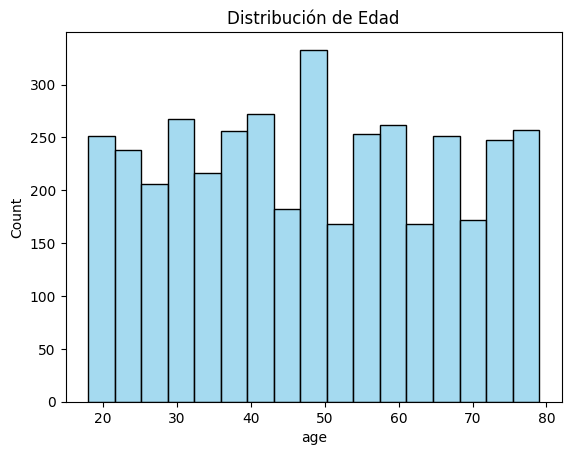

In [28]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', color='skyblue')
plt.title('Distribución de Edad')
plt.show()

💡Insights: 
- Distribución uniforme, la pablacion esta concentrada entre los 18 y 80 años, pico mas alto entre los 45 y 50 años por lo que se podria implementar campañas de fidelizacion en este segmento 

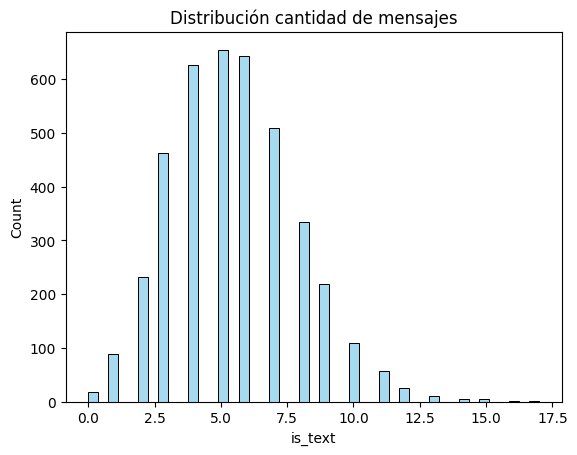

In [29]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='is_text', color='skyblue')
plt.title('Distribución cantidad de mensajes')
plt.show()

💡Insights: Sesgo hacia la derecha, con nayor pico entre 5 y 6 mensajes, lo que sognifica que la nayoria de usurios no usan mucho los mesnajes 
- ....

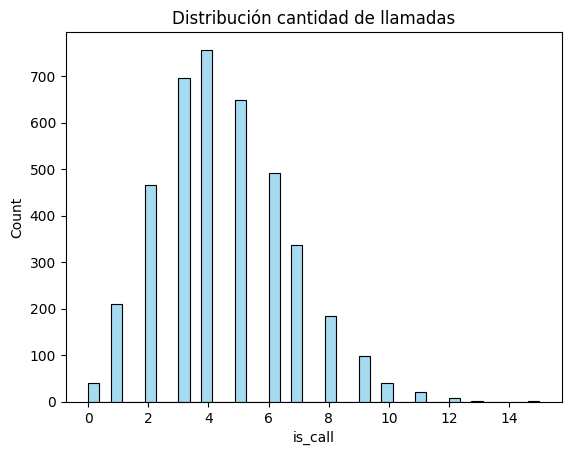

In [30]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='is_call', color='skyblue')
plt.title('Distribución cantidad de llamadas')
plt.show()

💡Insights: 
- Distribución sesgo hacia la derecha
- Uso Ocasional: 0 a 2 llamadas.
- Uso Frecuente (Core): 3 a 7 llamadas.
- Uso Intensivo: Más de 8 llamadas

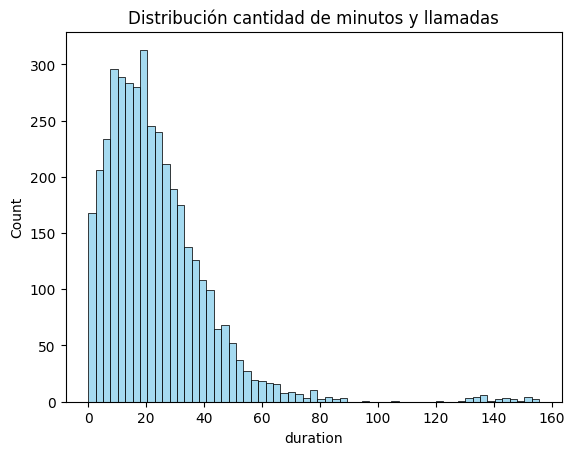

In [31]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="duration", color='skyblue')
plt.title('Distribución cantidad de minutos y llamadas')
plt.show()

💡Insights: 
- Se mantiene el sesgo hacia la derecha, la mayoria de usuarios consumen entre 10 y 30 minutos, siendo 20 minutos el pico mas alto, después de los 90 minutos, la frecuencia cae drásticamente y aparecen pequeñas barras aisladas entre los 130 y 160 minutos lo que puede deberse a pocos usuarios con necesidades intensas en comunicacion

### 
5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


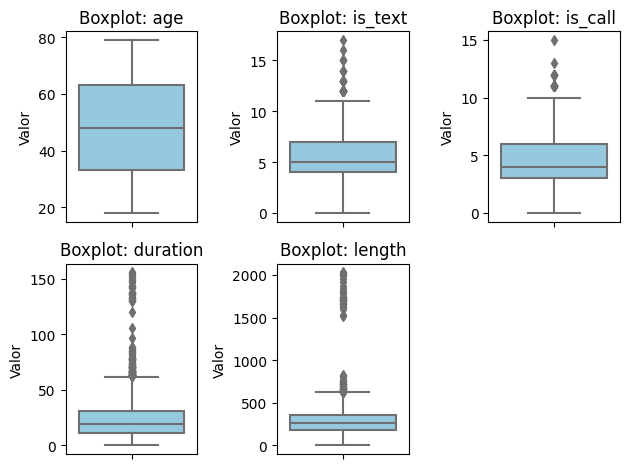

In [38]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'is_text', 'is_call', 'duration', 'length']

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i) # 2 filas, 3 columnas para acomodar las 5 variables
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: pocos outliers, arriba de 10 y de 12
- cant_llamadas: igual que en mensjes, pocos outliers, arriba de 10
- cant_minutos_llamada: presentan mucho mas outliers con consumo muy por encima del promedio

In [44]:
# Calcular límites con el método IQR
columnas_limites = ["age", "is_text", "is_call", "duration", "length"]
for col in columnas_limites:
   Q1 = user_profile[col].quantile(0.25)
   Q3 = user_profile[col].quantile(0.75)
    
   IQR = Q3 - Q1                               



In [46]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,is_text,is_call,duration,length
count,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054,288.128032
std,17.689919,2.358416,2.144238,18.168095,180.906841
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000,184.000000
50%,48.000000,5.000000,4.000000,19.780000,268.000000
75%,63.000000,7.000000,6.000000,31.415000,361.000000
max,79.000000,17.000000,15.000000,155.690000,2028.000000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  mantener, no son errores sino que representan a usuarios con comunicacion escrita mas activa 
- cant_llamadas: mantener o no outliers, porqué?
  mantener, aunque hay usuarios con 15 llamadas frente a la mediana de 4, estos representan a necesidades    de mayorm comunicacion, son ususrios activos
- cant_minutos_llamada: mantener o no outliers, porqué?
  mantener, aunque es la variable que reprsenta mayor sesgo, permite evaluar campañas especiales para        mensajes ilimitados y/o llamadas ilimitadas 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['is_call'] < 5) & (user_profile['is_text'] < 5),
    (user_profile['is_call'] < 10) & (user_profile['is_text'] < 10)
]
opciones = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,length,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso


### 
6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
condiciones_edad = [
    (user_profile['age'] < 30),  # Joven
    (user_profile['age'] < 60)   # Adulto
]
opciones_edad = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')


In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 
Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


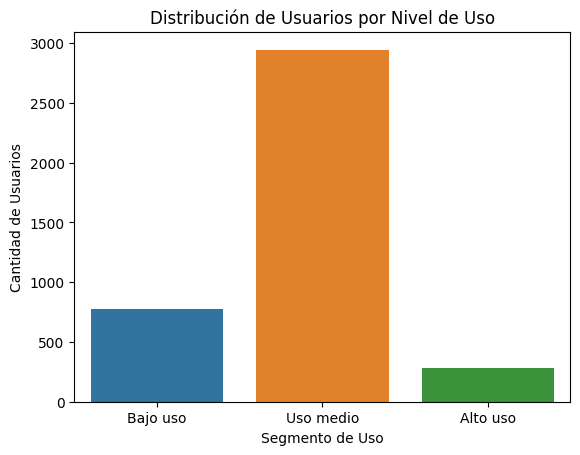

In [51]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Nivel de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

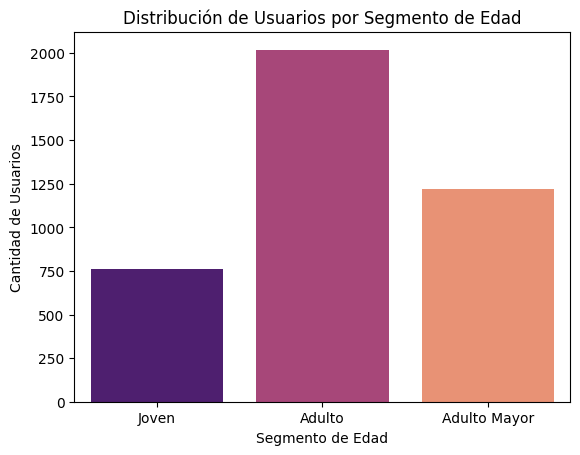

In [52]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

al inicio del proyecto, los datos presentaban inconsistencias críticas que afectaban la precisión del análisis:

   - Problemas en age (Edad): Se detectaron valores centinela (como -999) y registros de fechas futuras         marcadas como errores de captura.

  - Volumen de afectación: Estos errores representaban una cantidad significativa de filas en la columna      de edad, requiriendo la imputación de valores mediante la mediana para no perder el 100% de la             representatividad de la muestra (4,000 registros totales).

  - Limpieza de formatos: Se normalizaron columnas de ubicación y nombres que contenían símbolos               innecesarios y asteriscos, asegurando la integridad de los datos para la segmentación.

    **Segmentación y Comportamiento**

 Identificamos patrones claros cruzando la edad y el nivel de actividad:

   - Por Edad: La base se concentra en el grupo 'Adulto' (30-59 años), con una media de 48 años. Los            'Jóvenes' (<30) y 'Adultos Mayores' (60+) muestran distribuciones más acotadas.

   - Por Uso: La mayoría de los clientes se clasifican en 'Bajo uso' (menos de 5 llamadas y mensajes),          mientras que el segmento de 'Alto uso' es impulsado por usuarios que superan los 10 registros en           alguna de las categorías.

     **Segmentos de Mayor Valor**

Para ConnectaTel, el segmento más valioso es el de Adultos con Alto Uso:

   - Razón: Este grupo combina estabilidad demográfica con una alta demanda de servicios. Son usuarios          que  generan el mayor tráfico de red y, por ende, la mayor facturación potencial, especialmente en la      duración de llamadas, que alcanza picos de hasta 155 minutos.

   **Patrones de Uso Extremo (Outliers)**

El análisis detectó valores atípicos significativos en el consumo:

   - Hallazgo: Los outliers en duration y length muestran usuarios que consumen hasta 6 veces más que el        promedio (media de 23 min vs. máx de 155 min).

   - Implicación de Negocio: Estos no son errores; son "Heavy Users". Representan una oportunidad               comercial alta pero también un riesgo de saturación de red o fuga si no cuentan con un plan que            soporte su volumen de comunicación.

  **Recomendaciones Estratégicas**

  - Plan "Premium Conectado": Crear un plan con minutos ilimitados o paquetes extensos (>150 min) diseñado     específicamente para el segmento de Alto Uso, capturando el valor que hoy se sale de los promedios         estándar.

  - Fidelización para Adultos Mayores: Dado que este grupo tiene un comportamiento estable, se recomienda      un plan con beneficios preferenciales, aprovechando la posición en Bogotá.

  - Monetización de Mensajes: Aunque el uso de SMS es bajo en general (media de 5 mensajes), existe un         nicho que llega a 17 mensajes. Se pueden ofrecer micro-paquetes de texto para los segmentos de Uso         Medio que están cerca de saltar a Alto Uso.

  - Estrategia de Captación Joven: Diseñar ofertas de entrada para el segmento 'Joven', enfocadas más en       datos o servicios digitales, ya que su volumen de llamadas actual es menor al del segmento adulto.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de valores centinela: Se identificaron registros con el valor -999 en la columna de edad, lo     cual representaba un error de captura que sesgaba el promedio poblacional.
- Registros de fechas inválidas: Se detectaron y marcaron como NA fechas futuras en el registro de           usuarios, asegurando que solo se analice información cronológicamente coherente.


🔍 **Segmentos por Edad**
- Predominio del segmento Adulto: La gran mayoría de los clientes se sitúa entre los 30 y 59 años, con una   media de 48.13 años, lo que indica una base de usuarios con estabilidad económica.
- Distribución Simétrica: El grupo 'Joven' y 'Adulto Mayor' presentan una distribución equilibrada, aunque   el valor máximo de 79 años confirma que no existen outliers de edad que deban ser eliminados.


📊 **Segmentos por Nivel de Uso**
- Concentración en Bajo Uso: El 75% de los usuarios realiza 6 llamadas o menos y envía 7 mensajes o menos,   lo que define el comportamiento estándar de la base.
- Presencia de Heavy Users: Se identificó un segmento de 'Alto Uso' con patrones extremos, donde algunos     usuarios alcanzan hasta 155.69 minutos de duración en llamadas.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Lanzamiento de Plan "Premium": Diseñar una oferta de minutos ilimitados dirigida al segmento Adulto de     Alto Uso
- Ajuste de Umbrales de Consumo: Establecer nuevos límites superiores en los planes actuales basados en el   Límite Superior IQR calculado (aprox. 31.4 min), para monetizar el exceso de uso de los outliers           actuales de manera justa.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`